# ML Training, MLflow Tracking & SHAP Explainability

This notebook trains 4 models for churn prediction, tracks experiments with MLflow, and generates SHAP explanations.

**Models:** Logistic Regression, Random Forest, XGBoost, LightGBM  
**Evaluation:** Stratified 5-fold CV, SMOTE on training folds only  
**Metrics:** F1-score, AUC-ROC, AUC-PR, Accuracy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, f1_score, accuracy_score,
    roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)

import mlflow
import mlflow.sklearn
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

## 1. Load Processed Data & Train/Test Split

In [2]:
df = pd.read_csv("../data/processed/engineered.csv")
print(f"Dataset: {df.shape}")

X = df.drop(columns=["Churn"])
y = df["Churn"]

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.2f}%")

Dataset: (5630, 31)
Features: 30
Target distribution:
Churn
0    4682
1     948
Name: count, dtype: int64
Churn rate: 16.84%


In [3]:
# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean()*100:.2f}% churn)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean()*100:.2f}% churn)")

Train: 4504 samples (16.83% churn)
Test:  1126 samples (16.87% churn)


## 2. Define Models

We use **SMOTE** inside an imbalanced-learn pipeline so oversampling only applies to training folds (no data leakage).

In [4]:
models = {
    "Logistic Regression": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42)),
    ]),
    "Random Forest": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)),
    ]),
    "XGBoost": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            eval_metric="logloss", random_state=42,
        )),
    ]),
    "LightGBM": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", LGBMClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            random_state=42, verbose=-1,
        )),
    ]),
}

print(f"Models to train: {list(models.keys())}")

Models to train: ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']


## 3. Stratified 5-Fold Cross-Validation + MLflow Tracking

In [5]:
# Set up MLflow
import os
mlflow.set_tracking_uri(os.path.abspath("../mlruns"))
mlflow.set_experiment("churn-prediction")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}

for name, pipeline in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    with mlflow.start_run(run_name=name):
        # Cross-validation
        cv_scores = cross_validate(
            pipeline, X_train, y_train, cv=cv,
            scoring=["f1", "roc_auc", "average_precision", "accuracy"],
            return_train_score=False,
        )

        # Print CV results
        cv_metrics = {
            "cv_f1": cv_scores["test_f1"].mean(),
            "cv_f1_std": cv_scores["test_f1"].std(),
            "cv_auc_roc": cv_scores["test_roc_auc"].mean(),
            "cv_auc_roc_std": cv_scores["test_roc_auc"].std(),
            "cv_auc_pr": cv_scores["test_average_precision"].mean(),
            "cv_auc_pr_std": cv_scores["test_average_precision"].std(),
            "cv_accuracy": cv_scores["test_accuracy"].mean(),
            "cv_accuracy_std": cv_scores["test_accuracy"].std(),
        }

        for k, v in cv_metrics.items():
            print(f"  {k}: {v:.4f}")

        # Fit on full training set
        pipeline.fit(X_train, y_train)

        # Predict on test set
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        # Test metrics
        test_metrics = {
            "test_f1": f1_score(y_test, y_pred),
            "test_auc_roc": roc_auc_score(y_test, y_proba),
            "test_auc_pr": average_precision_score(y_test, y_proba),
            "test_accuracy": accuracy_score(y_test, y_pred),
        }

        print(f"\n  --- Test Set ---")
        for k, v in test_metrics.items():
            print(f"  {k}: {v:.4f}")

        # Log to MLflow
        # Log hyperparameters
        clf = pipeline.named_steps["clf"]
        mlflow.log_params({p: str(v) for p, v in clf.get_params().items()})

        # Log all metrics
        mlflow.log_metrics({**cv_metrics, **test_metrics})

        # Log model
        mlflow.sklearn.log_model(pipeline, artifact_path="model")

        # Store results
        results[name] = {
            **cv_metrics,
            **test_metrics,
            "pipeline": pipeline,
            "y_pred": y_pred,
            "y_proba": y_proba,
        }

print("\n\nAll models trained and logged to MLflow!")

2026/04/02 03:29:05 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.



Training: Logistic Regression


2026/04/02 03:29:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/02 03:29:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  cv_f1: 0.5833
  cv_f1_std: 0.0320
  cv_auc_roc: 0.8668
  cv_auc_roc_std: 0.0150
  cv_auc_pr: 0.6107
  cv_auc_pr_std: 0.0460
  cv_accuracy: 0.8317
  cv_accuracy_std: 0.0146

  --- Test Set ---
  test_f1: 0.5672
  test_auc_roc: 0.8620
  test_auc_pr: 0.6070
  test_accuracy: 0.8171


...

2026/04/02 03:29:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/02 03:29:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  cv_f1: 0.8477
  cv_f1_std: 0.0214
  cv_auc_roc: 0.9750
  cv_auc_roc_std: 0.0036
  cv_auc_pr: 0.9166
  cv_auc_pr_std: 0.0100
  cv_accuracy: 0.9507
  cv_accuracy_std: 0.0060

  --- Test Set ---
  test_f1: 0.9574
  test_auc_roc: 0.9983
  test_auc_pr: 0.9914
  test_accuracy: 0.9858


2026/04/02 03:29:18 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.




All models trained and logged to MLflow!


## 4. Model Comparison

In [6]:
# Comparison table
comparison = pd.DataFrame({
    name: {
        "CV F1": f"{r['cv_f1']:.4f} ± {r['cv_f1_std']:.4f}",
        "CV AUC-ROC": f"{r['cv_auc_roc']:.4f} ± {r['cv_auc_roc_std']:.4f}",
        "CV AUC-PR": f"{r['cv_auc_pr']:.4f} ± {r['cv_auc_pr_std']:.4f}",
        "CV Accuracy": f"{r['cv_accuracy']:.4f} ± {r['cv_accuracy_std']:.4f}",
        "Test F1": f"{r['test_f1']:.4f}",
        "Test AUC-ROC": f"{r['test_auc_roc']:.4f}",
        "Test AUC-PR": f"{r['test_auc_pr']:.4f}",
        "Test Accuracy": f"{r['test_accuracy']:.4f}",
    }
    for name, r in results.items()
}).T

comparison

,CV F1,CV AUC-ROC,CV AUC-PR,CV Accuracy,Test F1,Test AUC-ROC,Test AUC-PR,Test Accuracy
Logistic Regression,0.5833 ± 0.0320,0.8668 ± 0.0150,0.6107 ± 0.0460,0.8317 ± 0.0146,0.5672,0.8620,0.6070,0.8171
Random Forest,0.7594 ± 0.0183,0.9551 ± 0.0070,0.8484 ± 0.0152,0.9178 ± 0.0058,0.8276,0.9793,0.9213,0.9378
XGBoost,0.8460 ± 0.0190,0.9735 ± 0.0035,0.9139 ± 0.0094,0.9507 ± 0.0050,0.9572,0.9981,0.9900,0.9858
LightGBM,0.8477 ± 0.0214,0.9750 ± 0.0036,0.9166 ± 0.0100,0.9507 ± 0.0060,0.9574,0.9983,0.9914,0.9858


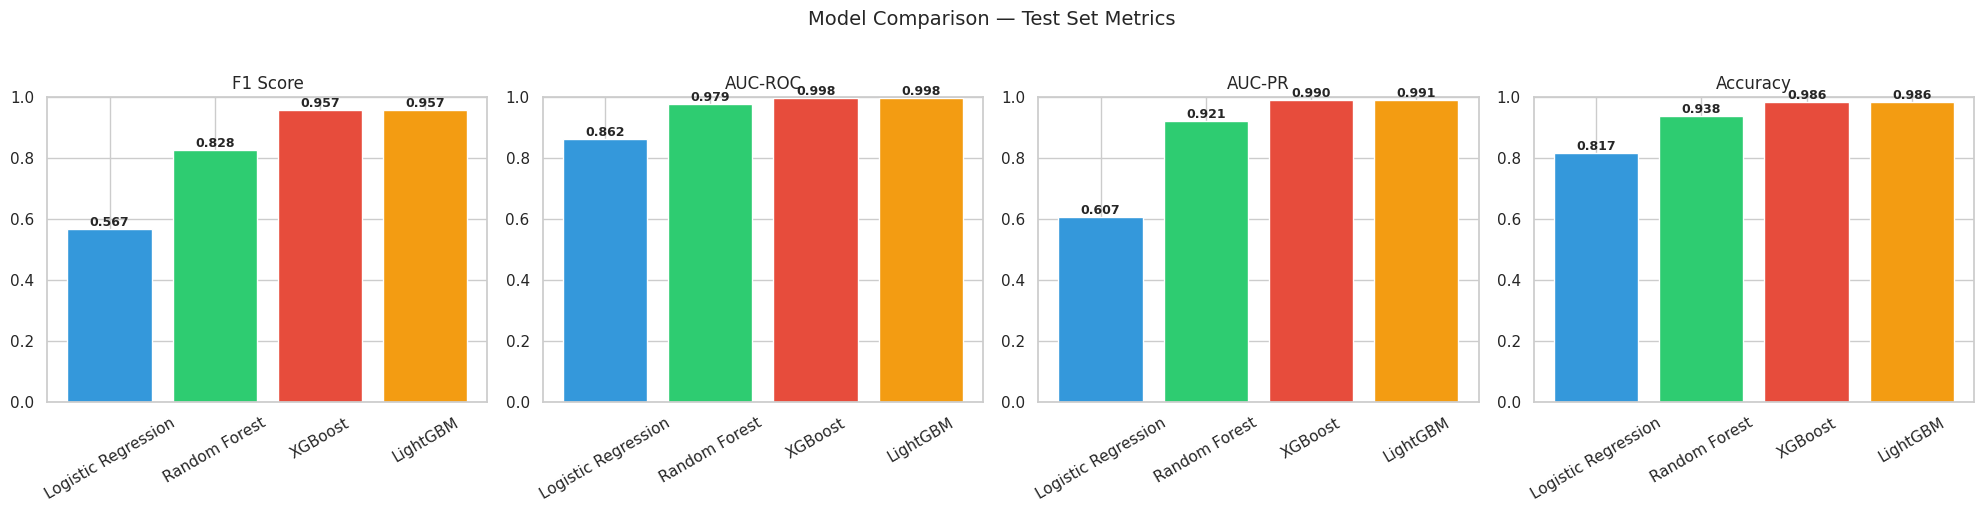

In [7]:
# Visual comparison — Test metrics bar chart
metric_names = ["test_f1", "test_auc_roc", "test_auc_pr", "test_accuracy"]
metric_labels = ["F1 Score", "AUC-ROC", "AUC-PR", "Accuracy"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (metric, label) in enumerate(zip(metric_names, metric_labels)):
    values = [results[name][metric] for name in results]
    bars = axes[i].bar(results.keys(), values, color=["#3498db", "#2ecc71", "#e74c3c", "#f39c12"])
    axes[i].set_title(label)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                     f"{val:.3f}", ha="center", fontsize=9, fontweight="bold")

plt.suptitle("Model Comparison — Test Set Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Confusion Matrices

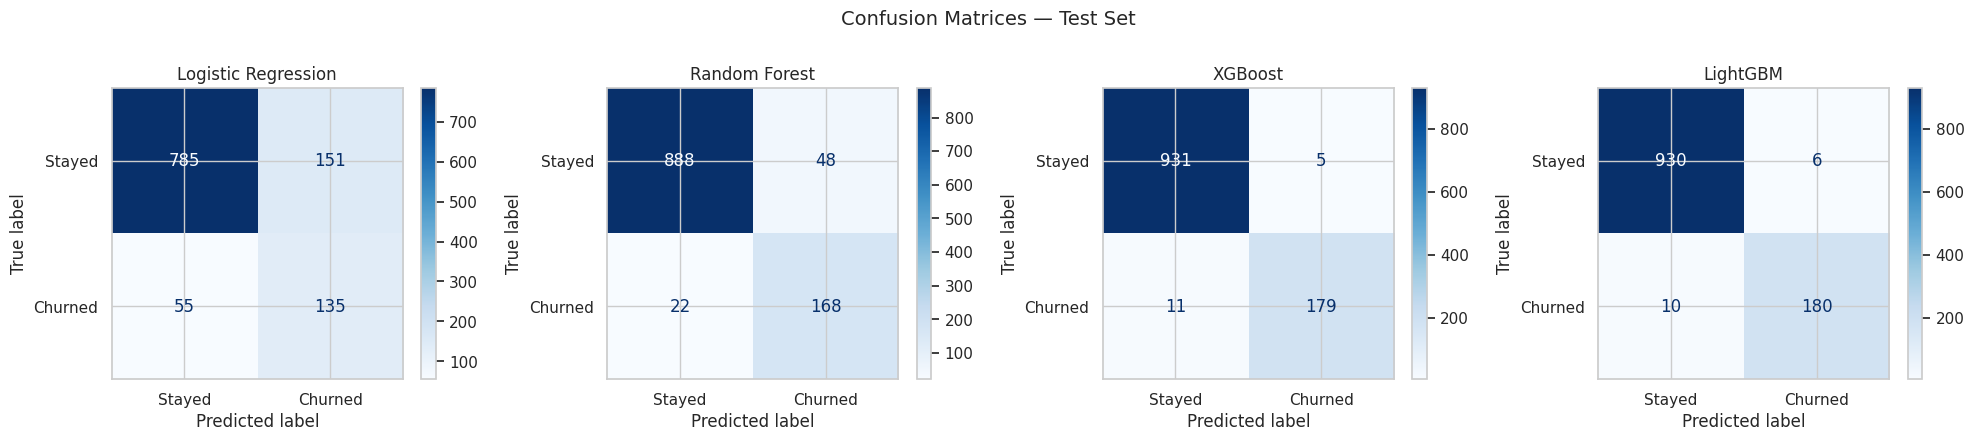

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r["y_pred"])
    ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(ax=axes[i], cmap="Blues")
    axes[i].set_title(name)

plt.suptitle("Confusion Matrices — Test Set", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

## 6. ROC Curves & Precision-Recall Curves

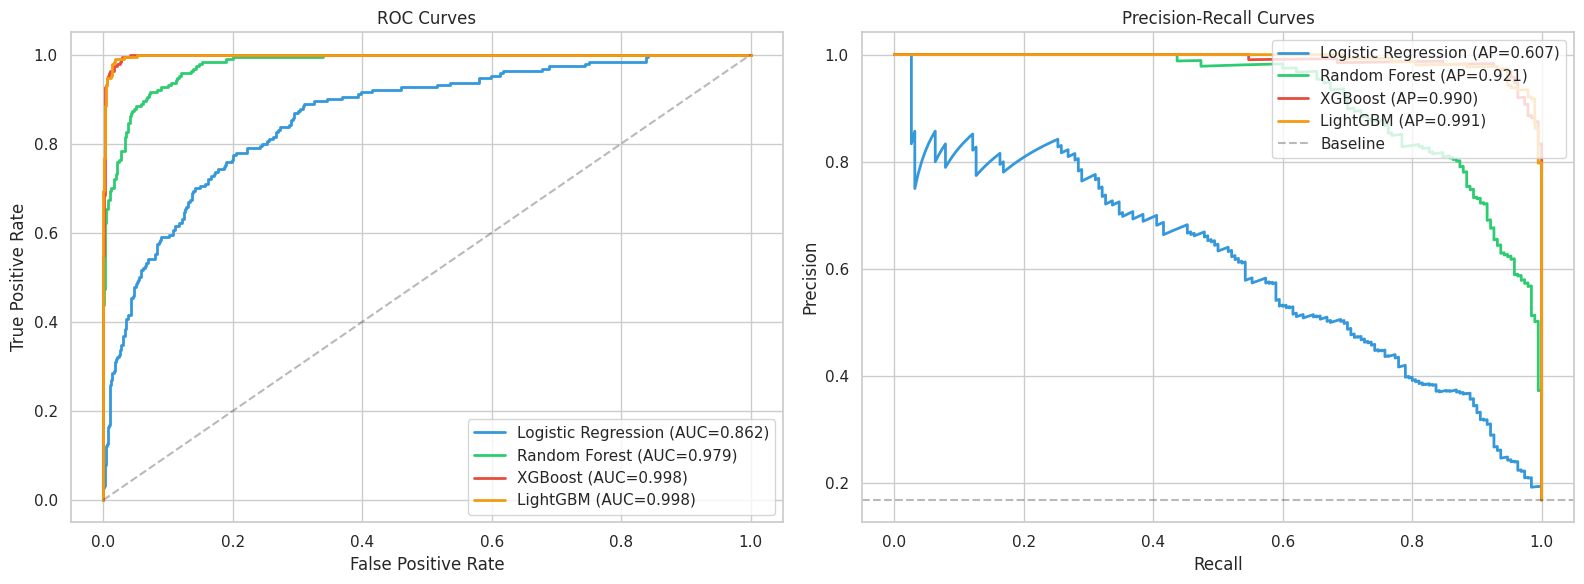

In [9]:
colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    auc = roc_auc_score(y_test, r["y_proba"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

# Precision-Recall Curves
for (name, r), color in zip(results.items(), colors):
    precision, recall, _ = precision_recall_curve(y_test, r["y_proba"])
    auc_pr = average_precision_score(y_test, r["y_proba"])
    axes[1].plot(recall, precision, label=f"{name} (AP={auc_pr:.3f})", color=color, linewidth=2)

axes[1].axhline(y=y_test.mean(), color="k", linestyle="--", alpha=0.3, label="Baseline")
axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 7. Classification Reports

In [10]:
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_test, r["y_pred"], target_names=["Stayed", "Churned"]))


Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.93      0.84      0.88       936
     Churned       0.47      0.71      0.57       190

    accuracy                           0.82      1126
   macro avg       0.70      0.77      0.73      1126
weighted avg       0.86      0.82      0.83      1126


Random Forest
              precision    recall  f1-score   support

      Stayed       0.98      0.95      0.96       936
     Churned       0.78      0.88      0.83       190

    accuracy                           0.94      1126
   macro avg       0.88      0.92      0.89      1126
weighted avg       0.94      0.94      0.94      1126


XGBoost
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99       936
     Churned       0.97      0.94      0.96       190

    accuracy                           0.99      1126
   macro avg       0.98      0.97      0.97      1126
weighted avg       0.99      

## 8. Select Best Model & Save Artifacts

In [11]:
# Select best model by test F1 score
best_name = max(results, key=lambda k: results[k]["test_f1"])
best_pipeline = results[best_name]["pipeline"]

print(f"Best model: {best_name}")
print(f"  Test F1:      {results[best_name]['test_f1']:.4f}")
print(f"  Test AUC-ROC: {results[best_name]['test_auc_roc']:.4f}")
print(f"  Test AUC-PR:  {results[best_name]['test_auc_pr']:.4f}")
print(f"  Test Accuracy: {results[best_name]['test_accuracy']:.4f}")

# Save best model
joblib.dump(best_pipeline, "../models/best_model.joblib")
print(f"\nSaved best model to models/best_model.joblib")

# Save feature names for later use
feature_names = X.columns.tolist()
joblib.dump(feature_names, "../models/feature_names.joblib")
print(f"Saved feature names to models/feature_names.joblib")

Best model: LightGBM
  Test F1:      0.9574
  Test AUC-ROC: 0.9983
  Test AUC-PR:  0.9914
  Test Accuracy: 0.9858

Saved best model to models/best_model.joblib
Saved feature names to models/feature_names.joblib


## 9. SHAP Explainability

Using SHAP (SHapley Additive exPlanations) to understand which features drive the model's predictions.

In [12]:
# Extract the classifier from the best pipeline
best_clf = best_pipeline.named_steps["clf"]

# Create SHAP explainer (TreeExplainer for tree-based models)
explainer = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_test)

# Save explainer for later use in FastAPI
joblib.dump(explainer, "../models/shap_explainer.joblib")
print(f"SHAP explainer created for: {best_name}")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Saved explainer to models/shap_explainer.joblib")

SHAP explainer created for: LightGBM
SHAP values shape: (1126, 30)
Saved explainer to models/shap_explainer.joblib


### 9.1 Global Feature Importance (Bar Plot)

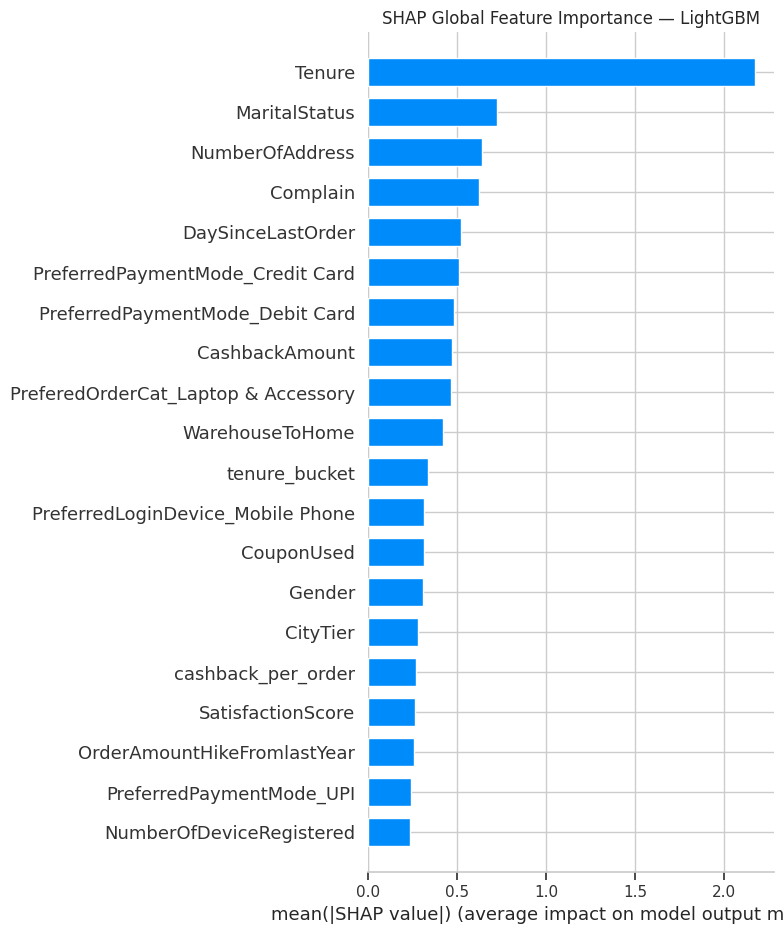

In [13]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title(f"SHAP Global Feature Importance — {best_name}")
plt.tight_layout()
plt.show()

### 9.2 Beeswarm Summary Plot

Shows the impact of each feature on predictions — color indicates feature value (red = high, blue = low).

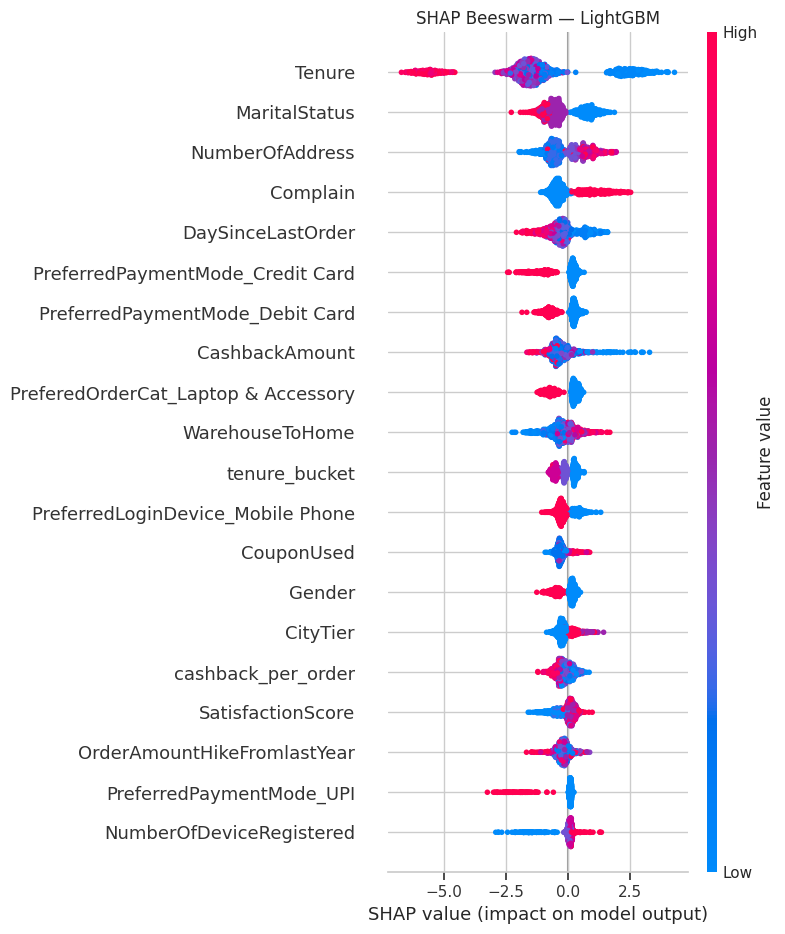

In [14]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title(f"SHAP Beeswarm — {best_name}")
plt.tight_layout()
plt.show()

### 9.3 Individual Waterfall Plots

Explaining specific customer predictions — shows how each feature pushes the prediction from the base value toward churn or stay.

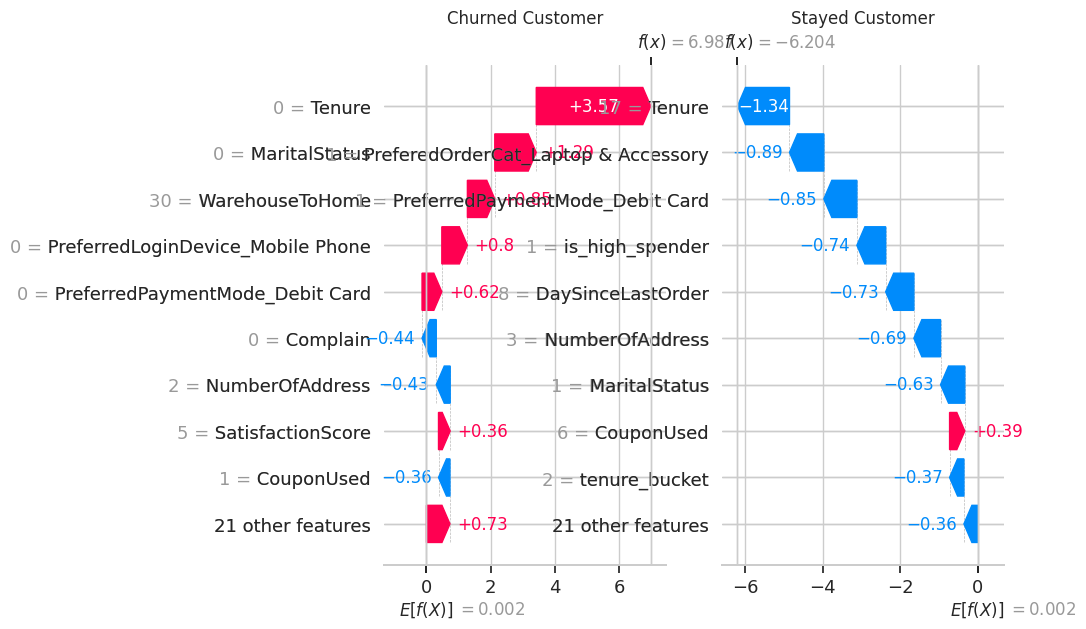

In [15]:
# Pick a churned customer and a stayed customer from test set
churned_idx = y_test[y_test == 1].index[0]
stayed_idx = y_test[y_test == 0].index[0]

churned_pos = list(X_test.index).index(churned_idx)
stayed_pos = list(X_test.index).index(stayed_idx)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Churned customer
plt.sca(axes[0])
shap_explanation_churned = shap.Explanation(
    values=shap_values[churned_pos],
    base_values=explainer.expected_value,
    data=X_test.iloc[churned_pos],
    feature_names=X_test.columns.tolist(),
)
shap.plots.waterfall(shap_explanation_churned, show=False)
axes[0].set_title("Churned Customer")

# Stayed customer
plt.sca(axes[1])
shap_explanation_stayed = shap.Explanation(
    values=shap_values[stayed_pos],
    base_values=explainer.expected_value,
    data=X_test.iloc[stayed_pos],
    feature_names=X_test.columns.tolist(),
)
shap.plots.waterfall(shap_explanation_stayed, show=False)
axes[1].set_title("Stayed Customer")

plt.tight_layout()
plt.show()

### 9.4 Dependence Plots

How a single feature impacts the prediction, with interaction effects shown by color.

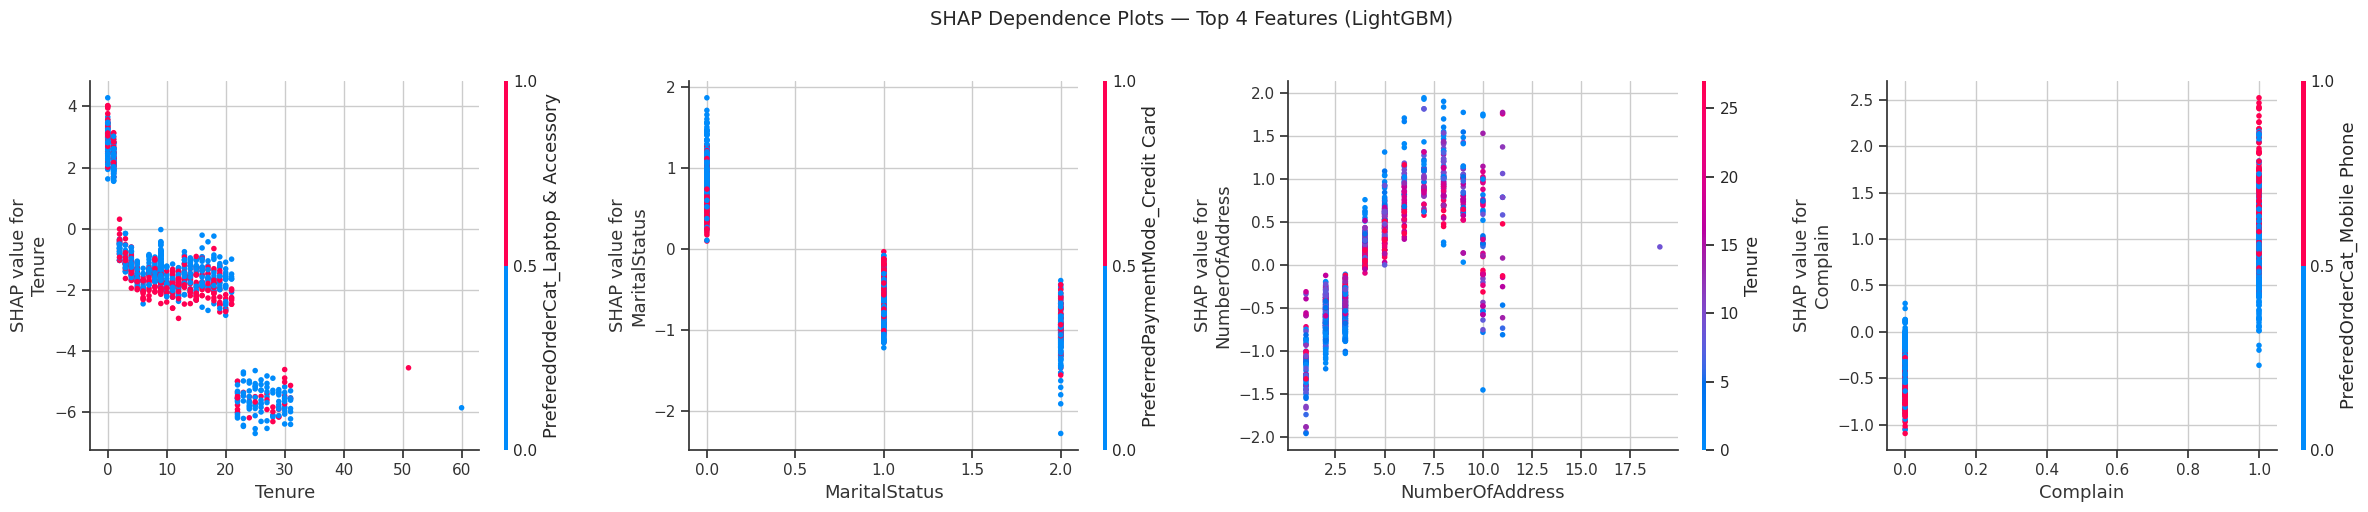

In [16]:
# Top 4 features by mean absolute SHAP value
mean_shap = np.abs(shap_values).mean(axis=0)
top_features = X_test.columns[np.argsort(mean_shap)[::-1][:4]].tolist()

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for i, feat in enumerate(top_features):
    plt.sca(axes[i])
    shap.dependence_plot(feat, shap_values, X_test, ax=axes[i], show=False)

plt.suptitle(f"SHAP Dependence Plots — Top 4 Features ({best_name})", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Summary

### Model Performance
- Trained 4 models with stratified 5-fold CV and SMOTE for class imbalance
- All experiments tracked in MLflow with hyperparameters, metrics, and model artifacts
- Best model selected by highest test F1 score

### SHAP Insights
- Global feature importance shows which features matter most for churn prediction
- Beeswarm plot reveals the direction of impact (e.g., low tenure → higher churn)
- Waterfall plots explain individual customer predictions
- Dependence plots show non-linear feature effects

### Saved Artifacts
- `models/best_model.joblib` — best pipeline (SMOTE + classifier)
- `models/feature_names.joblib` — feature column names
- `models/shap_explainer.joblib` — SHAP explainer for API use
- MLflow runs in `mlruns/` — viewable with `mlflow ui`